#**Movie Success Prediction System - Data Visualization**

#**1. Importing Libraries**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_style("whitegrid")

#**2. Loading Dataset**

In [25]:
df = pd.read_excel('/content/movies_cleaned.xlsx')

In [26]:
df.head(3)

,Unnamed: 0,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_month,release_day,roi,roi_class
0,1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,7,2,13.078468,blockbuster
1,2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,6,20,29.909726,blockbuster
2,3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,7,2,23.843868,blockbuster


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     5475 non-null   int64  
 1   name           5475 non-null   object 
 2   rating         5457 non-null   object 
 3   genre          5475 non-null   object 
 4   year           5475 non-null   int64  
 5   released       5475 non-null   object 
 6   score          5472 non-null   float64
 7   votes          5472 non-null   float64
 8   director       5475 non-null   object 
 9   writer         5475 non-null   object 
 10  star           5475 non-null   object 
 11  country        5475 non-null   object 
 12  budget         4376 non-null   float64
 13  gross          5377 non-null   float64
 14  company        5463 non-null   object 
 15  runtime        5473 non-null   float64
 16  release_month  5475 non-null   int64  
 17  release_day    5475 non-null   int64  
 18  roi     

In [28]:
print("Rows and Columns:", df.shape)

Rows and Columns: (5475, 20)


In [29]:
df.isnull().sum()

,0
Unnamed: 0,0
name,0
rating,18
genre,0
year,0
released,0
score,3
votes,3
director,0
writer,0


In [30]:
df = df.dropna(subset=['budget', 'gross', 'score', 'votes', 'genre', 'runtime', 'director'])

In [31]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4325, 20)


In [32]:
df['budget'] = df['budget'].astype(int)
df['gross'] = df['gross'].astype(int)
df['score'] = df['score'].astype(float)
df['votes'] = df['votes'].astype(int)

#**3. Defining Success**

In [33]:
df['roi'] = df['gross'] / df['budget']

bins = [0, 0.5, 1, 2, float("inf")]

labels = ["flop", "below_avg", "hit", "blockbuster"]

df['success'] = pd.cut(
    df['roi'],
    bins=bins,
    labels=labels
)

In [34]:
print(df['success'].value_counts())

success
blockbuster    2139
hit             883
flop            706
below_avg       597
Name: count, dtype: int64


#**4. Budget vs Gross Revenue**

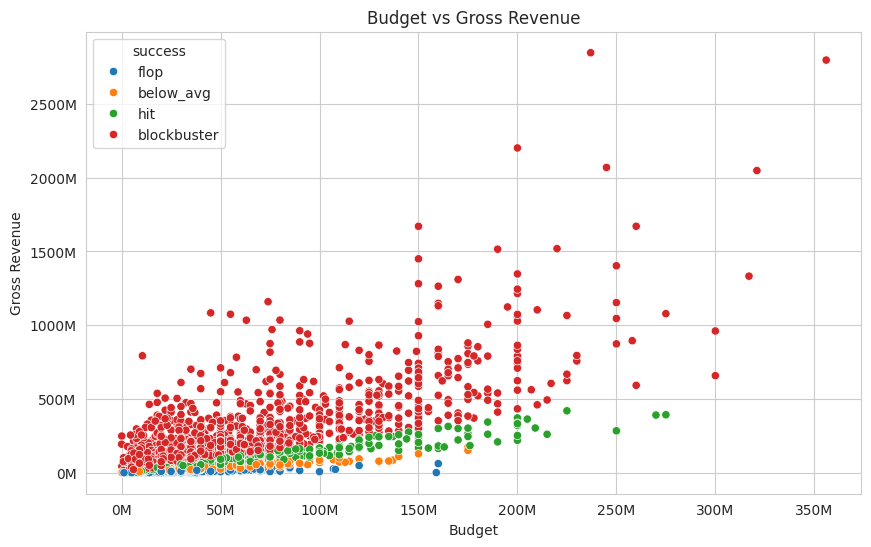

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='budget',
    y='gross',
    hue='success',
    data=df
)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')

plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Budget vs Gross Revenue')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')

plt.show()

#**5. Genre vs Average Gross**

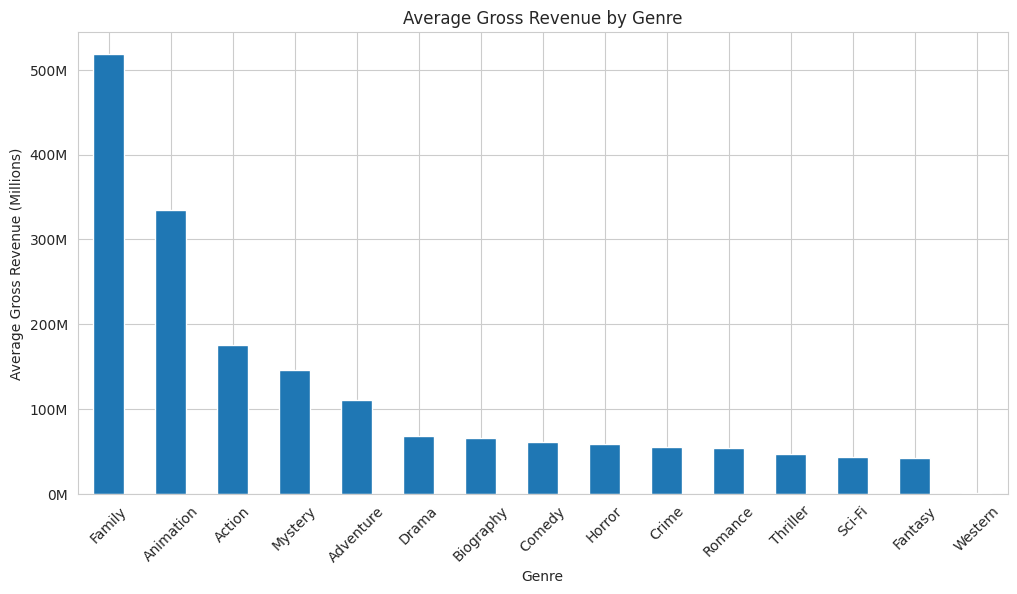

In [36]:
genre_gross = (
    df.groupby('genre')['gross']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

genre_gross.plot(kind='bar')

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Average Gross Revenue by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Gross Revenue (Millions)')

plt.xticks(rotation=45)

plt.show()

#**6. IMDB Score vs Gross**

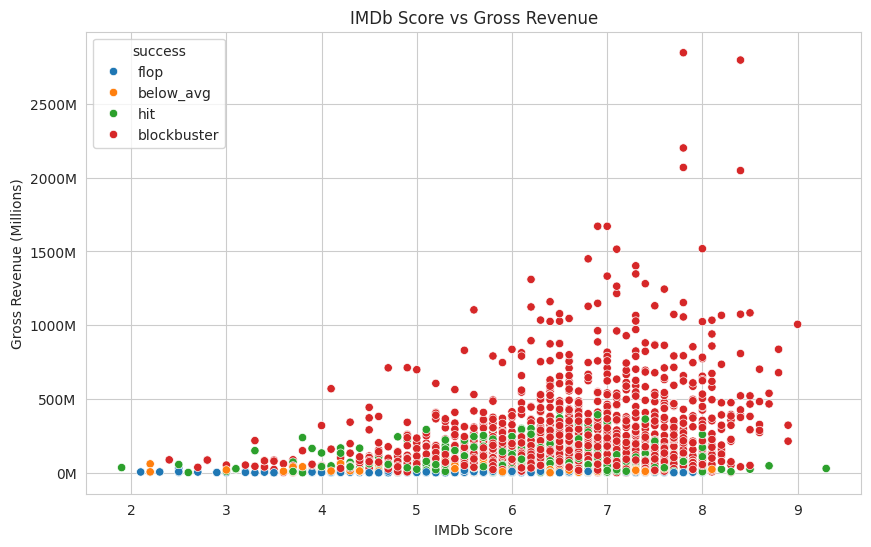

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='score',
    y='gross',
    hue='success',
    data=df
)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('IMDb Score vs Gross Revenue')
plt.xlabel('IMDb Score')
plt.ylabel('Gross Revenue (Millions)')

plt.show()

#**7. Runtime vs Success**

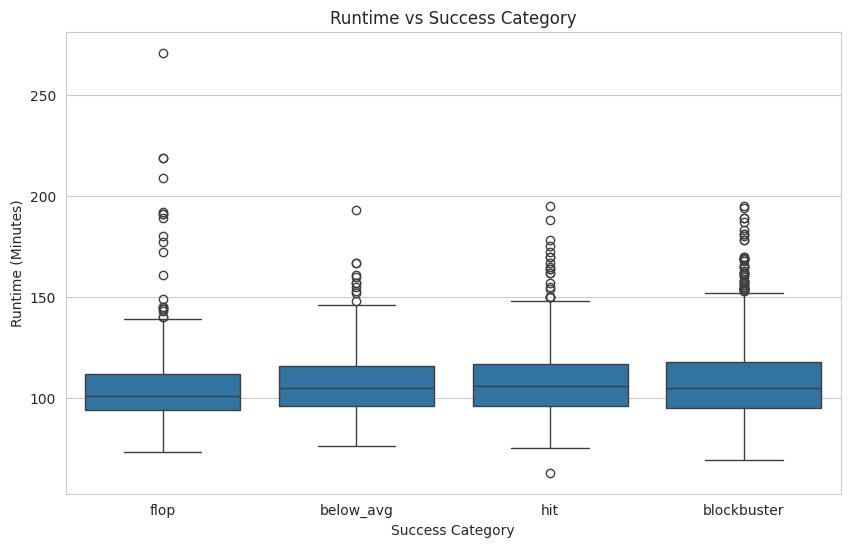

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='success',
    y='runtime',
    data=df,
    order=['flop', 'below_avg', 'hit', 'blockbuster']
)

plt.title('Runtime vs Success Category')
plt.xlabel('Success Category')
plt.ylabel('Runtime (Minutes)')

plt.show()

#**8. Success by Genre**

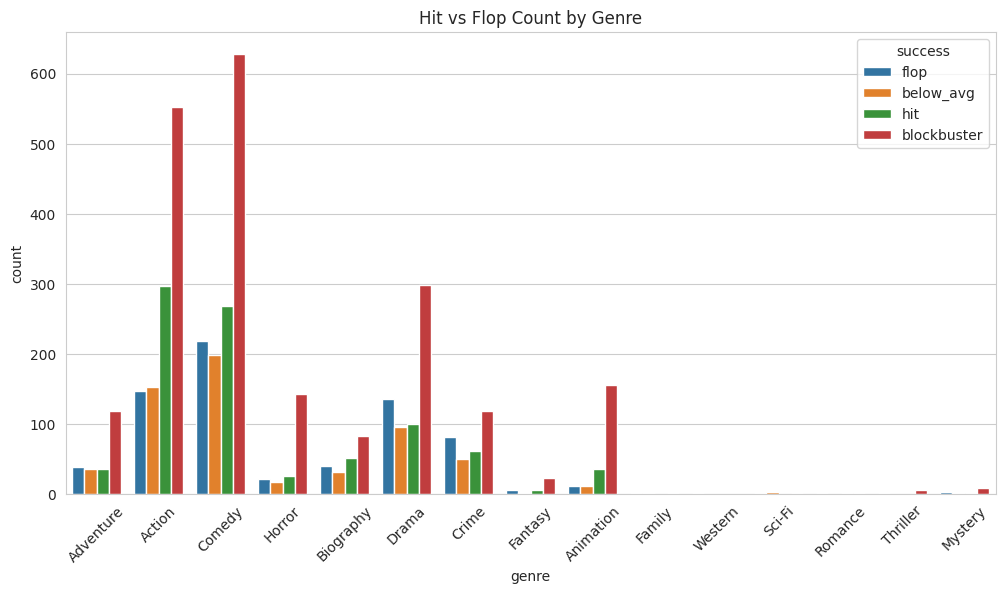

In [39]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='genre',
    hue='success',
    data=df
)

plt.title('Hit vs Flop Count by Genre')

plt.xticks(rotation=45)

plt.show()

#**9. Votes vs Gross Revenue**

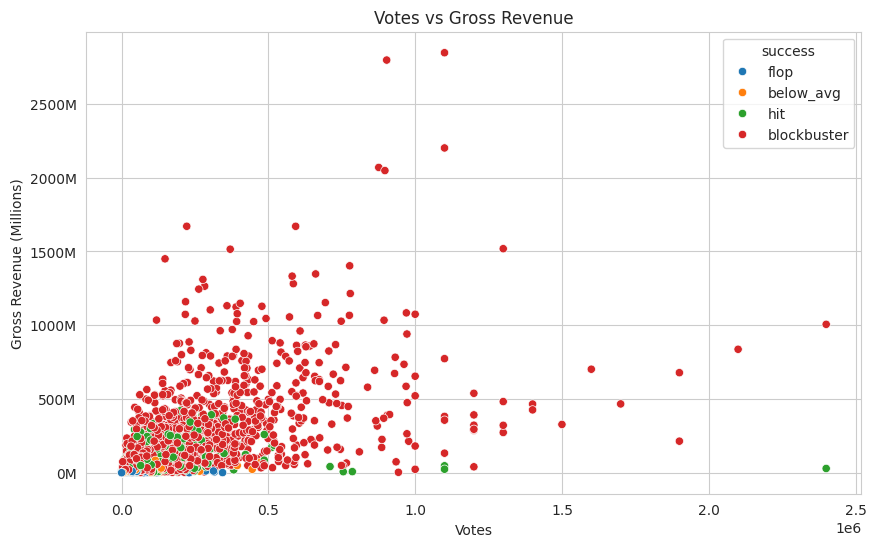

In [40]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='votes',
    y='gross',
    hue='success',
    data=df
)

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Votes vs Gross Revenue')
plt.xlabel('Votes')
plt.ylabel('Gross Revenue (Millions)')

plt.show()

#**10. Top 10 Directors by Average Gross Revenue**

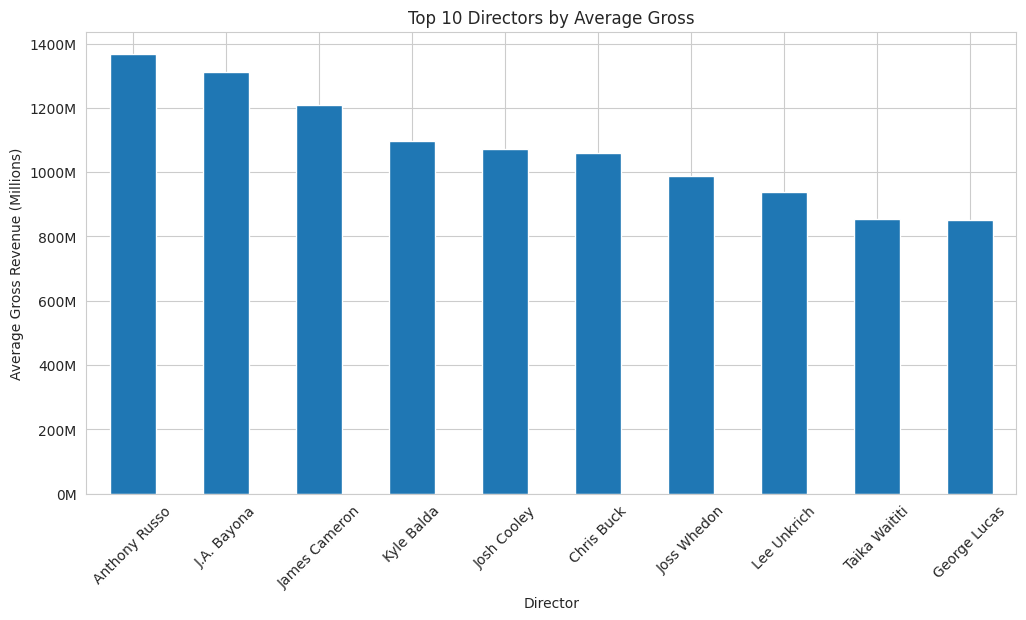

In [41]:
top_directors = (
    df.groupby('director')['gross']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_directors.plot(kind='bar')

formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Top 10 Directors by Average Gross')
plt.xlabel('Director')
plt.ylabel('Average Gross Revenue (Millions)')

plt.xticks(rotation=45)

plt.show()

#**11. Correlation Heatmap**

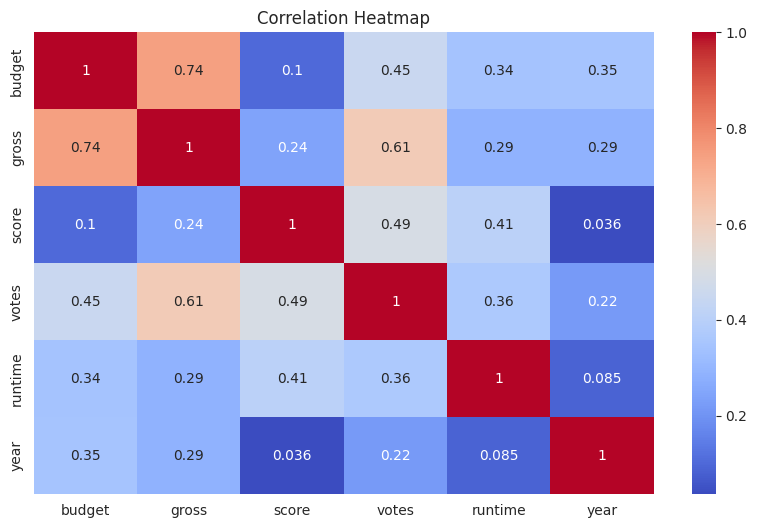

In [42]:
numeric_df = df[['budget', 'gross', 'score', 'votes', 'runtime', 'year']]

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [43]:
corr = df[['budget','gross','votes','score','runtime','roi']].corr()

print(corr['gross'].sort_values(ascending=False))

gross      1.000000
budget     0.741565
votes      0.612267
runtime    0.287923
score      0.240817
roi        0.015754
Name: gross, dtype: float64


#**12. Insights**

1. Higher-budget movies generally earn higher revenue.
2. Popular movies with more votes tend to perform better financially.
3. Blockbusters generate much higher ROI than other movies.
4. Some genres consistently achieve higher box office collections.
5. Higher IMDb ratings are linked with better revenue performance.
6. Release month influences movie earnings and audience turnout.
7. Blockbuster movies often have slightly longer runtimes.